# 📊 VibeSight — Data Engineering Pipeline
**Project:** AI-based Sentiment Analytics for Tokopedia Product Reviews  
**Program:** Pijak × IBM SkillsBuild Capstone Project  
**Peran:** Data Engineer  
**Nama:** Nurhayati Kusumaning Ayu (APC617D6X0220)  
**Sumber Data:** [Tokopedia Product Reviews 2025 — Kaggle](https://www.kaggle.com/datasets/salmanabdu/tokopedia-product-reviews-2025)  
**Versi Pipeline:** v1.0  

---

## 🎯 Tujuan Notebook Ini

Notebook ini merupakan **tanggung jawab penuh Data Engineer** dalam tim VibeSight.  
Fungsinya adalah memastikan bahwa data yang diterima dari sumber mentah (raw) diproses  
secara sistematis hingga menghasilkan dataset yang **bersih, konsisten, dan siap digunakan**  
oleh tim AI Engineer dan ML Engineer untuk proses pemodelan.

> **Analogi sederhana:**  
> Bayangkan data mentah seperti bahan makanan yang baru datang dari pasar — belum dicuci,  
> belum dipotong, ada yang busuk, ada yang tidak standar ukurannya.  
> Tugas Data Engineer adalah menyiapkan bahan tersebut agar **chef (AI Engineer)  
> bisa langsung memasak** tanpa khawatir soal kualitas bahan.

---

## 🗺️ Alur Pipeline (24 Tahap)

| No | Tahap | Output |
|---|---|---|
| 1 | Data Ingestion | DataFrame raw |
| 2 | Initial Assessment | Summary struktur |
| 3 | Data Understanding | Kolom terpilih |
| 4 | Duplicate Handling | Data tanpa duplikat |
| 5 | Missing Values | Data tanpa null |
| 6 | Data Type Fix | Tipe data sesuai |
| 7 | Format Standardization | Data seragam |
| 8 | Value Validation | Data valid |
| 9 | Outlier Handling | Data lebih stabil |
| 10 | Text Cleaning | Clean text |
| 11 | Text Normalization | Teks baku |
| 12 | Stopword Removal | Teks lebih ringkas |
| 13 | Stemming | Teks terstruktur |
| 14 | Feature Engineering | Kolom baru |
| 15 | Feature Validation | Fitur valid |
| 16 | Encoding | Data numerik |
| 17 | Data Leakage Check | Dataset aman |
| 18 | Train-Test Split | Train & test set |
| 19 | Imbalance Check | Insight distribusi |
| 20 | Anomaly Detection | Kolom anomaly flag |
| 21 | Final Quality Check | Data bersih |
| 22 | Data Versioning | File versioned |
| 23 | Documentation | Dokumen pipeline |
| 24 | Final Export | CSV ML-ready |

---
## ⚙️ Instalasi & Import Library

**Mengapa perlu library ini?**  
Setiap library memiliki fungsi spesifik — seperti alat di kotak perkakas. Kita tidak bisa  
memaku dengan obeng. Masing-masing library dipilih sesuai kebutuhan tahap pipeline.

In [22]:
# ============================================================
# INSTALASI LIBRARY YANG DIPERLUKAN
# Jalankan cell ini sekali saat pertama kali setup environment
# ============================================================

# PySastrawi  : library khusus stemming Bahasa Indonesia
#               mengubah kata berimbuhan ke bentuk dasar
#               contoh: "berlari" → "lari", "memakan" → "makan"
# nltk        : Natural Language Toolkit — kamus stopword & tools NLP
# scikit-learn: untuk encoding label dan train-test split
# imbalanced-learn: untuk analisis ketidakseimbangan kelas (opsional)

!pip install PySastrawi nltk scikit-learn imbalanced-learn --quiet

In [23]:
# ============================================================
# IMPORT SEMUA LIBRARY YANG DIPERLUKAN
# ============================================================

# --- Library Standar Python ---
import os           # untuk operasi file system (buat folder, cek path)
import re           # untuk operasi regex (pola teks)
import json         # untuk menyimpan dokumentasi dalam format JSON
import warnings     # untuk menyembunyikan peringatan yang tidak penting
from datetime import datetime  # untuk timestamp versioning

# --- Manipulasi Data ---
import pandas as pd    # DataFame — seperti Excel tapi di Python
import numpy as np     # komputasi numerik (array, matematika)

# --- Visualisasi ---
import matplotlib.pyplot as plt   # grafik dasar
import matplotlib.ticker as mtick # format angka di grafik
import seaborn as sns              # grafik statistik yang lebih indah

# --- NLP (Natural Language Processing) ---
import nltk
from nltk.corpus import stopwords           # daftar kata umum bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # stemming Bahasa Indonesia

# --- Machine Learning (untuk encoding & split) ---
from sklearn.preprocessing import LabelEncoder   # ubah label teks ke angka
from sklearn.model_selection import train_test_split  # bagi data train & test

# --- Konfigurasi Tampilan ---
warnings.filterwarnings('ignore')  # sembunyikan warning tidak penting
pd.set_option('display.max_columns', None)   # tampilkan semua kolom
pd.set_option('display.max_colwidth', 100)   # lebar kolom maksimal 100 karakter
pd.set_option('display.float_format', '{:,.2f}'.format)  # format angka desimal

# Download resource NLTK yang diperlukan
nltk.download('stopwords', quiet=True)

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


---
## ⚙️ Konfigurasi Path

**Mengapa perlu konfigurasi path?**  
Agar seluruh anggota tim bisa menjalankan notebook ini dari komputer masing-masing  
tanpa perlu mengubah path satu per satu. Cukup sesuaikan `BASE_DIR` dengan lokasi project.

In [24]:
# ============================================================
# KONFIGURASI PATH PROJECT
# Sesuaikan BASE_DIR dengan lokasi folder project di komputer Anda
# ============================================================

# os.path.abspath('..') → mengambil path absolut folder parent dari notebooks/
# Ini berarti: naik satu tingkat dari /notebooks/ ke root project VibeSight
# Contoh: jika notebook ada di C:/VibeSight/notebooks/ maka BASE_DIR = C:/VibeSight/
BASE_DIR = os.path.abspath('..')

# Path untuk data mentah (file asli dari Kaggle, jangan pernah diubah!)
RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'tokopedia_product_reviews_2025.csv')

# Path untuk menyimpan hasil data yang sudah bersih
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

# Path untuk laporan & grafik (untuk dokumentasi capstone)
REPORT_DIR = os.path.abspath(os.path.join(BASE_DIR, 'reports'))

# Buat folder jika belum ada
# exist_ok=True berarti tidak error jika folder sudah ada
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Tampilkan path yang aktif agar bisa diverifikasi
print(f"📁 BASE_DIR      : {BASE_DIR}")
print(f"📄 RAW DATA      : {RAW_DATA_PATH}")
print(f"📂 PROCESSED DIR : {PROCESSED_DIR}")
print(f"📊 REPORT DIR    : {REPORT_DIR}")

📁 BASE_DIR      : d:\CAPSTONE\Data_Engineer
📄 RAW DATA      : d:\CAPSTONE\Data_Engineer\data\raw\tokopedia_product_reviews_2025.csv
📂 PROCESSED DIR : d:\CAPSTONE\Data_Engineer\data\processed
📊 REPORT DIR    : d:\CAPSTONE\Data_Engineer\reports


---
## TAHAP 1 — Data Ingestion

**Apa masalahnya?**  
Data belum masuk ke sistem. Masih berupa file CSV di komputer/Kaggle.

**Mengapa perlu dilakukan?**  
Semua analisis berikutnya bergantung pada data yang sudah terbaca dengan benar.  
Jika proses load data gagal atau salah, seluruh pipeline akan menghasilkan output yang keliru.

**Solusi:**  
Load file CSV menggunakan `pandas.read_csv()` dan simpan ke dalam DataFrame.

In [25]:
# ============================================================
# TAHAP 1 — DATA INGESTION
# Memasukkan data CSV ke dalam DataFrame pandas
# ============================================================

# pd.read_csv() membaca file CSV dan mengubahnya menjadi DataFrame
# DataFrame seperti tabel Excel — ada baris (rows) dan kolom (columns)
# low_memory=False → agar pandas tidak salah mendeteksi tipe data
df_raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)

# Membuat salinan untuk diproses — data asli (df_raw) tidak akan diubah
# Seperti membuat fotokopi dokumen sebelum dicoret-coret
df = df_raw.copy()

# Rekam jumlah baris awal untuk perbandingan di akhir pipeline
initial_row_count = len(df)

print(f"✅ Data berhasil dimuat.")
print(f"   Jumlah baris    : {len(df):,}")
print(f"   Jumlah kolom    : {len(df.columns)}")
print(f"   Ukuran di memori: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Data berhasil dimuat.
   Jumlah baris    : 65,543
   Jumlah kolom    : 13
   Ukuran di memori: 46.48 MB


---
## TAHAP 2 — Initial Assessment

**Apa masalahnya?**  
Kita belum tahu apa isi dataset — berapa kolom, tipe datanya apa, ada yang kosong tidak.

**Mengapa perlu dilakukan?**  
Seperti dokter yang melakukan pemeriksaan awal sebelum menentukan diagnosa.  
Tanpa assessment, kita bisa salah menangani data.

**Solusi:**  
Periksa shape, kolom, tipe data, dan ringkasan statistik dasar.

In [26]:
# ============================================================
# TAHAP 2 — INITIAL ASSESSMENT
# Memahami struktur dan kondisi awal dataset
# ============================================================

print("=" * 60)
print("RINGKASAN AWAL DATASET")
print("=" * 60)

# df.shape → mengembalikan tuple (jumlah_baris, jumlah_kolom)
print(f"\n📐 Dimensi Dataset : {df.shape[0]:,} baris × {df.shape[1]} kolom")

print("\n📋 Daftar Kolom & Tipe Data:")
# df.dtypes → menampilkan tipe data setiap kolom
# object = teks, int64 = bilangan bulat, float64 = bilangan desimal
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    print(f"   {col:<22} | tipe: {str(df[col].dtype):<10} | null: {null_count:>5} ({null_pct:.1f}%)")

print("\n📊 5 Baris Pertama Dataset:")
# df.head(5) → tampilkan 5 baris pertama sebagai sampel
display(df.head(5))

print("\n📈 Statistik Kolom Numerik:")
# df.describe() → ringkasan statistik: rata-rata, min, max, standar deviasi
display(df.describe())

RINGKASAN AWAL DATASET

📐 Dimensi Dataset : 65,543 baris × 13 kolom

📋 Daftar Kolom & Tipe Data:
   review_text            | tipe: object     | null:     0 (0.0%)
   review_date            | tipe: object     | null:     0 (0.0%)
   review_id              | tipe: int64      | null:     0 (0.0%)
   product_name           | tipe: object     | null:     0 (0.0%)
   product_category       | tipe: object     | null:     0 (0.0%)
   product_variant        | tipe: object     | null: 38794 (59.2%)
   product_price          | tipe: int64      | null:     0 (0.0%)
   product_url            | tipe: object     | null:     0 (0.0%)
   product_id             | tipe: int64      | null:     0 (0.0%)
   rating                 | tipe: int64      | null:     0 (0.0%)
   sold_count             | tipe: int64      | null:     0 (0.0%)
   shop_id                | tipe: int64      | null:     0 (0.0%)
   sentiment_label        | tipe: object     | null:     0 (0.0%)

📊 5 Baris Pertama Dataset:


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagai...",2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-17314...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan ...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-17314...,4601033481,5,1000000,8672687,positive
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sel...",2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-17314...,4601033481,5,1000000,8672687,positive
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-17314...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-17314...,4601033481,5,1000000,8672687,positive



📈 Statistik Kolom Numerik:


,review_id,product_price,product_id,rating,sold_count,shop_id
count,"65,543.00","65,543.00","65,543.00","65,543.00","65,543.00","65,543.00"
mean,"981,414,343.32","542,129.53","24,474,817,101.09",4.89,"1,954.92","76,156,735,628,296,320.00"
std,"419,332,399.65","2,365,556.69","38,707,173,773.11",0.49,"18,244.03","751,657,336,816,289,152.00"
min,"10,272,017.00",100.00,"4,298,375.00",1.00,6.00,605.00
25%,"718,224,045.50","29,900.00","1,446,882,217.00",5.00,100.00,"2,298,522.00"
50%,"974,004,766.00","80,000.00","4,769,574,591.00",5.00,500.00,"5,801,280.00"
75%,"1,145,966,987.00","214,687.00","15,346,048,884.00",5.00,"1,000.00","9,061,811.00"
max,"1,809,541,621.00","99,999,000.00","102,677,804,179.00",5.00,"1,000,000.00","7,496,219,804,483,554,304.00"


---
## TAHAP 3 — Data Understanding

**Apa masalahnya?**  
Dataset memiliki 13 kolom — tidak semua relevan untuk analisis sentimen.

**Mengapa perlu dilakukan?**  
Kolom yang tidak relevan hanya menambah beban komputasi tanpa memberikan nilai analitik.  
Ibarat membawa koper 30 kg padahal yang dibutuhkan hanya 5 kg.

**Solusi:**  
Identifikasi dan dokumentasikan fungsi setiap kolom, lalu tentukan kolom yang dipertahankan.

In [27]:
# ============================================================
# TAHAP 3 — DATA UNDERSTANDING
# Identifikasi peran setiap kolom dalam konteks project
# ============================================================

# Kamus penjelasan setiap kolom (berdasarkan eksplorasi awal)
column_info = {
    'review_text'     : {'fungsi': 'Teks ulasan pembeli (FITUR UTAMA untuk NLP)',        'dipakai': True},
    'review_date'     : {'fungsi': 'Tanggal ulasan ditulis (untuk analisis tren waktu)', 'dipakai': True},
    'review_id'       : {'fungsi': 'ID unik setiap ulasan (sebagai primary key)',        'dipakai': True},
    'product_name'    : {'fungsi': 'Nama produk yang diulas',                            'dipakai': True},
    'product_category': {'fungsi': 'Kategori produk (untuk segmentasi analisis)',        'dipakai': True},
    'product_variant' : {'fungsi': 'Varian produk — banyak kosong, opsional',           'dipakai': False},
    'product_price'   : {'fungsi': 'Harga produk (untuk feature engineering harga)',     'dipakai': True},
    'product_url'     : {'fungsi': 'URL produk — tidak dipakai untuk modeling',         'dipakai': False},
    'product_id'      : {'fungsi': 'ID produk untuk referensi',                         'dipakai': True},
    'rating'          : {'fungsi': 'Rating 1–5 dari pembeli (berkorelasi dengan sentimen)', 'dipakai': True},
    'sold_count'      : {'fungsi': 'Jumlah terjual (indikator popularitas produk)',      'dipakai': True},
    'shop_id'         : {'fungsi': 'ID toko — untuk analisis per-toko jika perlu',      'dipakai': True},
    'sentiment_label' : {'fungsi': 'Label sentimen (TARGET/OUTPUT model)',               'dipakai': True},
}

print("📋 ANALISIS KOLOM DATASET:")
print("-" * 70)
for col, info in column_info.items():
    status = "✅ DIPAKAI" if info['dipakai'] else "❌ DIBUANG"
    print(f"{status} | {col:<22} → {info['fungsi']}")

# Daftar kolom yang TIDAK dibutuhkan untuk modeling
# product_url : hanya link, tidak ada nilai informasi
# product_variant : 59% kosong (38794/65543 rows)
KOLOM_DIBUANG = ['product_url', 'product_variant']

# Drop kolom tidak relevan
# axis=1 berarti drop kolom (bukan baris)
# inplace=True berarti ubah langsung di DataFrame yang sama
df.drop(columns=KOLOM_DIBUANG, inplace=True)

print(f"\n✅ Kolom dibuang   : {KOLOM_DIBUANG}")
print(f"   Sisa kolom      : {df.shape[1]} kolom")
print(f"   Kolom aktif     : {list(df.columns)}")

📋 ANALISIS KOLOM DATASET:
----------------------------------------------------------------------
✅ DIPAKAI | review_text            → Teks ulasan pembeli (FITUR UTAMA untuk NLP)
✅ DIPAKAI | review_date            → Tanggal ulasan ditulis (untuk analisis tren waktu)
✅ DIPAKAI | review_id              → ID unik setiap ulasan (sebagai primary key)
✅ DIPAKAI | product_name           → Nama produk yang diulas
✅ DIPAKAI | product_category       → Kategori produk (untuk segmentasi analisis)
❌ DIBUANG | product_variant        → Varian produk — banyak kosong, opsional
✅ DIPAKAI | product_price          → Harga produk (untuk feature engineering harga)
❌ DIBUANG | product_url            → URL produk — tidak dipakai untuk modeling
✅ DIPAKAI | product_id             → ID produk untuk referensi
✅ DIPAKAI | rating                 → Rating 1–5 dari pembeli (berkorelasi dengan sentimen)
✅ DIPAKAI | sold_count             → Jumlah terjual (indikator popularitas produk)
✅ DIPAKAI | shop_id               

---
## TAHAP 4 — Duplicate Handling

**Apa masalahnya?**  
Data duplikat terjadi ketika baris yang sama muncul lebih dari sekali.  
Penyebab: error saat scraping, data digabungkan dari dua sumber, atau input ganda.

**Mengapa perlu dilakukan?**  
Data duplikat membuat model 'hafal' data tertentu — bukan belajar. Ini disebut **data leakage**.  
Akibatnya: akurasi model di training tinggi tapi di dunia nyata jelek.

**Solusi:**  
Deteksi dan hapus baris yang memiliki `review_id` atau konten identik.

In [28]:
# ============================================================
# TAHAP 4 — DUPLICATE HANDLING
# Deteksi dan hapus data yang muncul lebih dari sekali
# ============================================================

sebelum = len(df)

# --- Cek 1: Duplikat berdasarkan SEMUA kolom ---
# df.duplicated() → mengembalikan True jika baris adalah salinan dari baris sebelumnya
duplikat_total = df.duplicated().sum()
print(f"Duplikat total (semua kolom) : {duplikat_total:,} baris")

# --- Cek 2: Duplikat berdasarkan review_id (ID unik ulasan) ---
# subset=['review_id'] → hanya cek kolom review_id saja
duplikat_id = df.duplicated(subset=['review_id']).sum()
print(f"Duplikat review_id           : {duplikat_id:,} baris")

# --- Cek 3: Duplikat berdasarkan teks ulasan yang persis sama ---
duplikat_teks = df.duplicated(subset=['review_text']).sum()
print(f"Duplikat review_text         : {duplikat_teks:,} baris")

# --- Hapus duplikat (prioritas: review_id sebagai primary key) ---
# keep='first' → pertahankan kemunculan pertama, hapus yang setelahnya
df.drop_duplicates(subset=['review_id'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)  # reset nomor baris setelah drop

sesudah = len(df)
print(f"\n✅ Sebelum: {sebelum:,} baris → Sesudah: {sesudah:,} baris")
print(f"   Data terhapus   : {sebelum - sesudah:,} baris")

Duplikat total (semua kolom) : 0 baris
Duplikat review_id           : 0 baris
Duplikat review_text         : 7,475 baris

✅ Sebelum: 65,543 baris → Sesudah: 65,543 baris
   Data terhapus   : 0 baris


---
## TAHAP 5 — Missing Values

**Apa masalahnya?**  
Beberapa sel kosong (NaN/null). Model ML tidak bisa memproses nilai kosong.

**Mengapa perlu dilakukan?**  
Nilai kosong di kolom kritis seperti `review_text` atau `sentiment_label`  
akan membuat model error atau menghasilkan prediksi yang salah.

**Solusi:**  
Kolom kritis → hapus barisnya. Kolom non-kritis → isi dengan nilai default.

In [29]:
# ============================================================
# TAHAP 5 — MISSING VALUES HANDLING
# Tangani nilai kosong secara selektif berdasarkan peran kolom
# ============================================================

print("🔍 Kondisi Missing Values per Kolom:")
missing_report = pd.DataFrame({
    'Jumlah Kosong': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
# Tampilkan hanya kolom yang ada nilai kosongnya
print(missing_report[missing_report['Jumlah Kosong'] > 0])

sebelum = len(df)

# --- Strategi 1: HAPUS baris jika kolom KRITIS kosong ---
# Kolom kritis adalah kolom yang WAJIB ada untuk analisis:
# - review_text    : tanpa teks, tidak ada yang dianalisis
# - sentiment_label: tanpa label, model tidak bisa belajar
# - rating         : dibutuhkan untuk validasi konsistensi label
KOLOM_KRITIS = ['review_text', 'sentiment_label', 'rating']
df.dropna(subset=KOLOM_KRITIS, inplace=True)

# --- Strategi 2: ISI nilai kosong untuk kolom non-kritis ---
# product_name kosong → isi dengan 'Produk Tidak Diketahui'
df['product_name'].fillna('Produk Tidak Diketahui', inplace=True)

# product_category kosong → isi dengan 'Lainnya'
df['product_category'].fillna('Lainnya', inplace=True)

# sold_count kosong → isi dengan median (lebih robust dari mean terhadap outlier)
df['sold_count'].fillna(df['sold_count'].median(), inplace=True)

# product_price kosong → isi dengan median harga
df['product_price'].fillna(df['product_price'].median(), inplace=True)

df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f"\n✅ Sebelum: {sebelum:,} baris → Sesudah: {sesudah:,} baris")
print(f"   Data terhapus: {sebelum - sesudah:,} baris (kolom kritis kosong)")
print(f"\n🔍 Verifikasi — Missing Values Tersisa:")
remaining = df.isnull().sum().sum()
print(f"   Total nilai kosong: {remaining}")

🔍 Kondisi Missing Values per Kolom:
Empty DataFrame
Columns: [Jumlah Kosong, Persentase (%)]
Index: []

✅ Sebelum: 65,543 baris → Sesudah: 65,543 baris
   Data terhapus: 0 baris (kolom kritis kosong)

🔍 Verifikasi — Missing Values Tersisa:
   Total nilai kosong: 0


---
## TAHAP 6 — Data Type Fix

**Apa masalahnya?**  
`review_date` masih bertipe `object` (teks), bukan tipe tanggal yang sesungguhnya.  
Kolom numerik seperti `shop_id` mungkin perlu disesuaikan.

**Mengapa perlu dilakukan?**  
Jika tanggal masih berupa teks, kita tidak bisa menghitung selisih hari, filter per bulan,  
atau membuat grafik tren waktu. Ibarat mencoba menjumlahkan kata '5' dengan angka 3.

**Solusi:**  
Konversi tipe data setiap kolom ke tipe yang sesuai dengan fungsinya.

In [30]:
# ============================================================
# TAHAP 6 — DATA TYPE FIX
# Konversi tipe data agar sesuai dengan fungsi setiap kolom
# ============================================================

print("Tipe data sebelum konversi:")
print(df.dtypes)

# --- Konversi review_date ke tipe datetime ---
# pd.to_datetime() mengubah string tanggal ke format datetime Python
# errors='coerce' → jika ada format tanggal yang aneh, jadikan NaT (Not a Time)
#                   daripada error yang menghentikan proses
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Hapus baris di mana tanggal tidak bisa dikonversi (NaT)
tanggal_error = df['review_date'].isnull().sum()
if tanggal_error > 0:
    print(f"⚠️  {tanggal_error} baris dengan tanggal tidak valid — dihapus")
    df.dropna(subset=['review_date'], inplace=True)

# --- Konversi kolom ID ke tipe string ---
# ID tidak memerlukan operasi matematika, lebih aman disimpan sebagai string
# Contoh: shop_id = 7496220000000000000 — jika int bisa kehilangan presisi
for id_col in ['review_id', 'product_id', 'shop_id']:
    df[id_col] = df[id_col].astype(str)

# --- Pastikan rating bertipe integer ---
df['rating'] = df['rating'].astype(int)

# --- Pastikan harga & sold_count bertipe integer ---
df['product_price'] = df['product_price'].astype(int)
df['sold_count'] = df['sold_count'].astype(int)

df.reset_index(drop=True, inplace=True)

print("\nTipe data setelah konversi:")
print(df.dtypes)
print(f"\n✅ Konversi tipe data selesai. Total baris: {len(df):,}")

Tipe data sebelum konversi:
review_text         object
review_date         object
review_id            int64
product_name        object
product_category    object
product_price        int64
product_id           int64
rating               int64
sold_count           int64
shop_id              int64
sentiment_label     object
dtype: object

Tipe data setelah konversi:
review_text                 object
review_date         datetime64[ns]
review_id                   object
product_name                object
product_category            object
product_price                int64
product_id                  object
rating                       int64
sold_count                   int64
shop_id                     object
sentiment_label             object
dtype: object

✅ Konversi tipe data selesai. Total baris: 65,543


---
## TAHAP 7 — Format Standardization

**Apa masalahnya?**  
Teks kategori mungkin tidak konsisten: `makanan & minuman`, `Makanan & Minuman`, `MAKANAN&MINUMAN`  
padahal merujuk pada hal yang sama.

**Mengapa perlu dilakukan?**  
Model menganggap ketiganya berbeda, sehingga data terpecah menjadi kategori-kategori kecil  
yang tidak akurat.

**Solusi:**  
Standarisasi format: lowercase, hapus spasi berlebih, konsistensi penulisan.

In [31]:
# ============================================================
# TAHAP 7 — FORMAT STANDARDIZATION
# Seragamkan format penulisan teks di seluruh kolom kategorikal
# ============================================================

# --- Standardisasi kolom kategori teks ---
# .str.strip()  → hapus spasi di awal dan akhir string
# .str.lower()  → ubah semua huruf ke huruf kecil (lowercase)
# Contoh: " Makanan & Minuman " → "makanan & minuman"
for col in ['product_category', 'product_name', 'sentiment_label']:
    df[col] = df[col].str.strip().str.lower()

# --- Standardisasi review_text ---
# Strip spasi di awal/akhir, normalisasi whitespace berlebih
# re.sub(r'\s+', ' ', teks) → ganti 2+ spasi/tab/newline dengan 1 spasi
df['review_text'] = df['review_text'].str.strip()
df['review_text'] = df['review_text'].apply(lambda x: re.sub(r'\s+', ' ', str(x)))

# --- Tampilkan distribusi setelah standardisasi ---
print("📊 Distribusi Kategori Produk (setelah standardisasi):")
print(df['product_category'].value_counts())

print("\n📊 Distribusi Sentiment Label (setelah standardisasi):")
print(df['sentiment_label'].value_counts())

print(f"\n✅ Standardisasi format selesai. Total baris: {len(df):,}")

📊 Distribusi Kategori Produk (setelah standardisasi):
product_category
makanan & minuman     17859
olahraga              15600
pertukangan           11500
kesehatan              8959
handphone & tablet     7423
elektronik             4202
Name: count, dtype: int64

📊 Distribusi Sentiment Label (setelah standardisasi):
sentiment_label
positive    63943
neutral       802
negative      798
Name: count, dtype: int64

✅ Standardisasi format selesai. Total baris: 65,543


---
## TAHAP 8 — Value Validation

**Apa masalahnya?**  
Mungkin ada nilai yang secara teknis valid (tidak null) tapi logikanya salah.  
Contoh: rating = 0, rating = 6, atau `sentiment_label = 'unknown'`.

**Mengapa perlu dilakukan?**  
Data yang logikanya salah akan menyesatkan model — seperti mengisi formulir  
dengan umur = -5 tahun, secara teknis terisi tapi tidak masuk akal.

**Solusi:**  
Definisikan nilai valid untuk setiap kolom dan hapus baris yang melanggar.

In [32]:
# ============================================================
# TAHAP 8 — VALUE VALIDATION
# Validasi nilai logis untuk mencegah data yang 'masuk akal secara teknis
# tapi tidak masuk akal secara bisnis'
# ============================================================

sebelum = len(df)

# --- Validasi 1: Rating harus antara 1–5 ---
# Rating di luar range ini adalah anomali data (error input atau scraping)
mask_rating_valid = df['rating'].between(1, 5)
invalid_rating = (~mask_rating_valid).sum()
print(f"Rating di luar range 1–5 : {invalid_rating:,} baris")
df = df[mask_rating_valid]

# --- Validasi 2: sentiment_label harus salah satu dari 3 nilai valid ---
LABEL_VALID = ['positive', 'negative', 'neutral']
# isin() → cek apakah nilai ada dalam daftar yang diizinkan
mask_label_valid = df['sentiment_label'].isin(LABEL_VALID)
invalid_label = (~mask_label_valid).sum()
print(f"Sentiment label tidak valid : {invalid_label:,} baris")
df = df[mask_label_valid]

# --- Validasi 3: review_text tidak boleh terlalu pendek ---
# Ulasan kurang dari 4 karakter tidak memberikan informasi sentimen
# Contoh: ulasan '.' atau 'ok' tidak bisa dianalisis maknanya
mask_text_valid = df['review_text'].str.len() >= 4
invalid_text = (~mask_text_valid).sum()
print(f"Review text terlalu pendek  : {invalid_text:,} baris")
df = df[mask_text_valid]

# --- Validasi 4: product_price harus positif dan realistis ---
# Harga Rp 100 mungkin masih valid (produk digital), tapi 0 atau negatif tidak
mask_price_valid = df['product_price'] > 0
invalid_price = (~mask_price_valid).sum()
print(f"Harga tidak valid (≤ 0)    : {invalid_price:,} baris")
df = df[mask_price_valid]

df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f"\n✅ Sebelum: {sebelum:,} baris → Sesudah: {sesudah:,} baris")
print(f"   Data tidak valid dihapus: {sebelum - sesudah:,} baris")

Rating di luar range 1–5 : 0 baris
Sentiment label tidak valid : 0 baris
Review text terlalu pendek  : 0 baris
Harga tidak valid (≤ 0)    : 0 baris

✅ Sebelum: 65,543 baris → Sesudah: 65,543 baris
   Data tidak valid dihapus: 0 baris


---
## TAHAP 9 — Outlier Handling

**Apa masalahnya?**  
Kolom numerik seperti `product_price` dan `sold_count` memiliki nilai ekstrem  
yang jauh di atas rata-rata. Contoh: harga Rp 99.999.000 atau terjual 1.000.000 unit.

**Mengapa perlu dilakukan?**  
Outlier ekstrem bisa mendistorsi analisis statistik dan memengaruhi performa model  
tertentu. Seperti satu siswa dengan nilai 100 bisa membuat rata-rata kelas terlihat tinggi  
padahal sebagian besar di bawah 50.

**Solusi:**  
Gunakan metode IQR (Interquartile Range) untuk mendeteksi outlier.  
Untuk project NLP ini, outlier di kolom numerik hanya di-*flag* (ditandai), tidak dihapus,  
karena fitur utama kita adalah teks.

In [33]:
# ============================================================
# TAHAP 9 — OUTLIER HANDLING
# Deteksi outlier pada kolom numerik dan tandai untuk referensi tim ML
# ============================================================

def detect_outliers_iqr(series, col_name):
    """
    Deteksi outlier menggunakan metode IQR (Interquartile Range).
    
    Cara kerja IQR:
    - Q1 = nilai di posisi 25% data (kuartil bawah)
    - Q3 = nilai di posisi 75% data (kuartil atas)
    - IQR = Q3 - Q1 (rentang tengah data)
    - Batas bawah = Q1 - 1.5 × IQR
    - Batas atas  = Q3 + 1.5 × IQR
    - Nilai di luar kedua batas ini dianggap outlier
    
    Analogi: jika tinggi badan rata-rata 160–175 cm,
    maka seseorang setinggi 230 cm adalah 'outlier' (sangat jarang).
    """
    Q1 = series.quantile(0.25)    # kuartil pertama
    Q3 = series.quantile(0.75)    # kuartil ketiga
    IQR = Q3 - Q1                  # jarak interkuartil
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier
    n_outlier = ((series < batas_bawah) | (series > batas_atas)).sum()
    pct = (n_outlier / len(series)) * 100
    
    print(f"   {col_name:<18} | Q1={Q1:>12,.0f} | Q3={Q3:>12,.0f} | "
          f"Outlier: {n_outlier:,} ({pct:.1f}%)")
    return batas_bawah, batas_atas

print("🔍 Deteksi Outlier pada Kolom Numerik (Metode IQR):")
KOLOM_NUMERIK_CEK = ['product_price', 'sold_count', 'rating']
for col in KOLOM_NUMERIK_CEK:
    detect_outliers_iqr(df[col], col)

# --- Untuk project NLP ini: FLAG outlier, jangan hapus ---
# Fitur utama analisis sentimen adalah review_text, bukan harga.
# Hapus outlier harga/sold_count bisa membuang ulasan valid.
# Sebagai gantinya, kita tandai saja dengan kolom flag.

Q1_price = df['product_price'].quantile(0.25)
Q3_price = df['product_price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Kolom baru: 1 jika outlier, 0 jika normal
df['is_price_outlier'] = (
    (df['product_price'] < Q1_price - 1.5 * IQR_price) |
    (df['product_price'] > Q3_price + 1.5 * IQR_price)
).astype(int)

print(f"\n✅ Outlier harga ditandai (kolom 'is_price_outlier')")
print(f"   Total baris outlier harga: {df['is_price_outlier'].sum():,}")
print(f"   Total baris dataset      : {len(df):,}")

🔍 Deteksi Outlier pada Kolom Numerik (Metode IQR):
   product_price      | Q1=      29,900 | Q3=     214,687 | Outlier: 8,486 (12.9%)
   sold_count         | Q1=         100 | Q3=       1,000 | Outlier: 9,514 (14.5%)
   rating             | Q1=           5 | Q3=           5 | Outlier: 4,018 (6.1%)

✅ Outlier harga ditandai (kolom 'is_price_outlier')
   Total baris outlier harga: 8,486
   Total baris dataset      : 65,543


---
## TAHAP 10 — Text Cleaning

**Apa masalahnya?**  
Teks ulasan penuh dengan noise: emoji, URL, tanda baca ganda, simbol tidak relevan.  
Contoh: *'Bagus bgt!! 🔥🔥 https://toko.com/promo suka bgt!!!!'*

**Mengapa perlu dilakukan?**  
Model NLP memproses kata-kata bermakna. Emoji, URL, dan simbol tidak menambah  
informasi sentimen tetapi menambah 'kebisingan' yang menyulitkan model.

**Solusi:**  
Hapus semua elemen non-teks menggunakan regex (Regular Expression).

In [34]:
# ============================================================
# TAHAP 10 — TEXT CLEANING
# Membersihkan teks dari noise: emoji, URL, simbol, angka terpisah
# ============================================================

def clean_text(teks):
    """
    Membersihkan satu baris teks dari berbagai noise.
    Setiap langkah di dalam fungsi ini berurutan dan saling bergantung.
    """
    # Pastikan input adalah string (bukan NaN atau angka)
    teks = str(teks)
    
    # Langkah 1: Hapus URL (http://, https://, www.)
    # r'http\S+' → cocok dengan 'http' diikuti karakter apa pun yang bukan spasi
    teks = re.sub(r'http\S+|www\.\S+', '', teks)
    
    # Langkah 2: Hapus emoji dan karakter unicode non-standar
    # \U0001F600-\U0001F64F → range emoji wajah/ekspresi
    # \U0001F300-\U0001F9FF → range emoji berbagai objek
    # \u2600-\u27BF          → simbol unicode umum (bintang, centang, dll)
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F9FF"
        u"\u2600-\u26FF"
        u"\u2700-\u27BF"
    "]+", flags=re.UNICODE)
    teks = emoji_pattern.sub('', teks)
    
    # Langkah 3: Hapus mention akun (@namauser)
    teks = re.sub(r'@\w+', '', teks)
    
    # Langkah 4: Hapus hashtag (#topik)
    teks = re.sub(r'#\w+', '', teks)
    
    # Langkah 5: Hapus karakter yang bukan huruf latin dan spasi
    # [^a-zA-Z\s] → hapus semua yang BUKAN huruf a-z, A-Z, atau whitespace
    teks = re.sub(r'[^a-zA-Z\s]', '', teks)
    
    # Langkah 6: Normalisasi spasi — ganti ≥2 spasi/newline dengan 1 spasi
    teks = re.sub(r'\s+', ' ', teks).strip()
    
    return teks

# Contoh sebelum dan sesudah
contoh_asli = df['review_text'].iloc[0]
print(f"Sebelum dibersihkan:\n{contoh_asli}\n")
print(f"Sesudah dibersihkan:\n{clean_text(contoh_asli)}")

# Terapkan fungsi ke seluruh kolom review_text
# .apply() → terapkan fungsi ke setiap baris satu per satu
df['review_text_clean'] = df['review_text'].apply(clean_text)

# Hapus baris jika setelah dibersihkan teks menjadi kosong atau terlalu pendek
sebelum = len(df)
df = df[df['review_text_clean'].str.len() >= 4]
df.reset_index(drop=True, inplace=True)

print(f"\n✅ Text cleaning selesai.")
print(f"   Baris dihapus (teks kosong setelah cleaning): {sebelum - len(df):,}")
print(f"   Total baris tersisa: {len(df):,}")

Sebelum dibersihkan:
baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller

Sesudah dibersihkan:
baru sekali ini terima brg dr belanja online dg packing super rapih dan aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp ternyata packing liar biasa rapi aman Kerem seller

✅ Text cleaning selesai.
   Baris dihapus (teks kosong setelah cleaning): 270
   Total baris tersisa: 65,273


---
## TAHAP 11 — Text Normalization

**Apa masalahnya?**  
Ulasan Tokopedia banyak menggunakan singkatan dan bahasa gaul:  
`'bgt'` → `'banget'`, `'gak'` → `'tidak'`, `'bs'` → `'bisa'`, `'tdk'` → `'tidak'`.

**Mengapa perlu dilakukan?**  
Model NLP perlu memahami 'bgt' dan 'banget' sebagai kata yang sama.  
Jika tidak dinormalisasi, model menganggap keduanya dua entitas berbeda,  
sehingga konteks maknanya terputus.

**Solusi:**  
Buat kamus normalisasi slang-to-baku dan terapkan penggantian kata.

In [35]:
# ============================================================
# TAHAP 11 — TEXT NORMALIZATION
# Ubah kata tidak baku / slang ke bentuk kata baku Bahasa Indonesia
# ============================================================

# Kamus normalisasi — dapat dikembangkan sesuai kebutuhan analisis
# Format: {'kata_tidak_baku': 'kata_baku'}
KAMUS_NORMALISASI = {
    # --- Singkatan Umum ---
    'bgt'    : 'banget',
    'bget'   : 'banget',
    'bngt'   : 'banget',
    'gak'    : 'tidak',
    'ga'     : 'tidak',
    'gk'     : 'tidak',
    'tdk'    : 'tidak',
    'tdk'    : 'tidak',
    'ngga'   : 'tidak',
    'nggak'  : 'tidak',
    'bs'     : 'bisa',
    'bisa'   : 'bisa',
    'ok'     : 'oke',
    'oke'    : 'oke',
    'oks'    : 'oke',
    'sy'     : 'saya',
    'aku'    : 'saya',
    'gw'     : 'saya',
    'gue'    : 'saya',
    'tp'     : 'tapi',
    'tapi'   : 'tapi',
    'krn'    : 'karena',
    'karna'  : 'karena',
    'krena'  : 'karena',
    'utk'    : 'untuk',
    'u'      : 'untuk',
    'dr'     : 'dari',
    'yg'     : 'yang',
    'dgn'    : 'dengan',
    'dg'     : 'dengan',
    'dlm'    : 'dalam',
    'sdh'    : 'sudah',
    'udah'   : 'sudah',
    'udh'    : 'sudah',
    'blm'    : 'belum',
    'blum'   : 'belum',
    'jd'     : 'jadi',
    'jadi'   : 'jadi',
    'sm'     : 'sama',
    'jg'     : 'juga',
    'cb'     : 'coba',
    'beli'   : 'beli',
    'pak'    : 'bapak',
    'bu'     : 'ibu',
    # --- Penilaian Positif ---
    'mantap' : 'mantap',
    'mantabs': 'mantap',
    'mantul' : 'mantap',
    'keren'  : 'bagus',
    'top'    : 'bagus',
    'jos'    : 'bagus',
    'oke banget' : 'sangat oke',
    # --- Penilaian Negatif ---
    'ancur'  : 'hancur',
    'anjir'  : 'tidak menyenangkan',
    'nyesel' : 'menyesal',
    'zonk'   : 'mengecewakan',
    'jelek'  : 'buruk',
    # --- E-commerce Spesifik ---
    'ongkir' : 'ongkos kirim',
    'packing': 'kemasan',
    'packingnya': 'kemasannya',
    'seller' : 'penjual',
    'cod'    : 'bayar di tempat',
    'ori'    : 'original',
    'asli'   : 'original',
    'sesuai pict' : 'sesuai gambar',
}

def normalize_text(teks):
    """
    Ganti kata tidak baku dengan padanan kata bakunya.
    Bekerja per kata (token) agar penggantian lebih presisi.
    """
    # .split() → pecah kalimat menjadi daftar kata
    # Contoh: 'bagus bgt' → ['bagus', 'bgt']
    kata_kata = teks.split()
    
    # Ganti setiap kata jika ada di kamus, jika tidak → biarkan
    # .get(kata, kata) → ambil nilai dari kamus, jika tidak ada kembalikan kata aslinya
    hasil = [KAMUS_NORMALISASI.get(kata, kata) for kata in kata_kata]
    
    # Gabungkan kembali menjadi kalimat
    return ' '.join(hasil)

# Terapkan ke kolom teks yang sudah dibersihkan
df['review_text_normalized'] = df['review_text_clean'].apply(normalize_text)

# Tampilkan contoh hasil normalisasi
contoh = df[df['review_text_clean'].str.contains('bgt|gak|tdk', case=False)].head(3)
if len(contoh) > 0:
    for _, row in contoh.iterrows():
        print(f"Sebelum: {row['review_text_clean'][:80]}")
        print(f"Sesudah: {row['review_text_normalized'][:80]}")
        print()

print(f"✅ Normalisasi teks selesai. Kamus berisi {len(KAMUS_NORMALISASI)} entri.")

Sebelum: cocok bgt aku sama telur nya nga Amis menurutku dan nga neg jadi nya diterima de
Sesudah: cocok banget saya sama telur nya nga Amis menurutku dan nga neg jadi nya diterim

Sebelum: Wah packingnya juara Super duper aman Kebetulan saat paket dtg di rumah ga ada o
Sesudah: Wah kemasannya juara Super duper aman Kebetulan saat paket dtg di rumah tidak ad

Sebelum: packing rapi ok bgt gak ada yg pecah segar telur nya meskipun ngirimnya agak tel
Sesudah: kemasan rapi oke banget tidak ada yang pecah segar telur nya meskipun ngirimnya 

✅ Normalisasi teks selesai. Kamus berisi 63 entri.


---
## TAHAP 12 — Stopword Removal

**Apa masalahnya?**  
Kalimat penuh dengan kata-kata yang sering muncul tetapi tidak bermakna:  
'yang', 'di', 'ke', 'dan', 'atau', 'ini', 'itu', dll.

**Mengapa perlu dilakukan?**  
Kata-kata ini muncul di ulasan positif MAUPUN negatif, sehingga tidak membantu  
model membedakan sentimen. Mereka hanya menambah dimensi yang tidak perlu.

**Solusi:**  
Hapus stopword Bahasa Indonesia menggunakan NLTK dan tambahkan daftar kustom.

In [36]:
# ============================================================
# TAHAP 12 — STOPWORD REMOVAL
# Hapus kata umum yang tidak berkontribusi pada analisis sentimen
# ============================================================

# Ambil daftar stopword Bahasa Indonesia dari NLTK
# NLTK sudah menyediakan ribuan kata umum yang bisa langsung dipakai
STOPWORDS_ID = set(stopwords.words('indonesian'))

# Tambahkan stopword kustom yang relevan untuk konteks e-commerce
# (tidak ada di daftar NLTK tapi juga tidak bermakna untuk sentimen)
STOPWORDS_TAMBAHAN = {
    'ya', 'yah', 'iya', 'oiya', 'oh', 'ah', 'eh', 'wah',
    'nih', 'sih', 'deh', 'dong', 'kok', 'aja', 'saja',
    'lah', 'dah', 'udah', 'emang', 'memang', 'hehe', 'haha',
    'hehehe', 'hm', 'hmm', 'yuk', 'yg', 'utk', 'dr',
    'jg', 'sy', 'lg', 'lagi', 'nah', 'mah', 'nih',
}
STOPWORDS_ID.update(STOPWORDS_TAMBAHAN)

# PENTING: Jangan hapus kata-kata yang BERMAKNA untuk sentimen!
# Kata seperti 'tidak', 'kurang', 'buruk', 'bagus' harus tetap ada.
# Contoh kasus: jika 'tidak' dihapus → 'tidak bagus' menjadi 'bagus' → salah!
KATA_PENTING = {'tidak', 'belum', 'kurang', 'bukan', 'jangan',
                'bagus', 'buruk', 'baik', 'jelek', 'puas',
                'kecewa', 'rusak', 'hancur', 'mantap', 'sesuai'}
STOPWORDS_ID -= KATA_PENTING  # hapus kata penting dari daftar stopword

def hapus_stopword(teks):
    """
    Hapus stopword dari teks.
    Hanya hapus kata yang ada di daftar stopword.
    """
    kata_kata = teks.split()
    # Pertahankan kata jika TIDAK ada di daftar stopword
    hasil = [kata for kata in kata_kata if kata not in STOPWORDS_ID]
    return ' '.join(hasil)

df['review_text_no_stop'] = df['review_text_normalized'].apply(hapus_stopword)

# Tampilkan perbandingan panjang teks sebelum dan sesudah
panjang_sebelum = df['review_text_normalized'].str.split().apply(len).mean()
panjang_sesudah = df['review_text_no_stop'].str.split().apply(len).mean()

print(f"✅ Stopword removal selesai.")
print(f"   Rata-rata kata per ulasan sebelum: {panjang_sebelum:.1f} kata")
print(f"   Rata-rata kata per ulasan sesudah: {panjang_sesudah:.1f} kata")
print(f"   Reduksi kata rata-rata: {((panjang_sebelum - panjang_sesudah) / panjang_sebelum * 100):.1f}%")
print(f"   Total stopword dalam kamus: {len(STOPWORDS_ID)}")

✅ Stopword removal selesai.
   Rata-rata kata per ulasan sebelum: 11.6 kata
   Rata-rata kata per ulasan sesudah: 8.7 kata
   Reduksi kata rata-rata: 24.9%
   Total stopword dalam kamus: 778


---
## TAHAP 13 — Stemming

**Apa masalahnya?**  
Bahasa Indonesia kaya imbuhan: `membeli`, `dibeli`, `pembelian`, `belian` — semuanya berasal  
dari kata dasar yang sama: `beli`. Model memperlakukan keempat kata ini sebagai 4 entitas berbeda.

**Mengapa perlu dilakukan?**  
Stemming menyederhanakan kosakata model, sehingga model tidak perlu belajar  
setiap varian imbuhan secara terpisah. Hasilnya: lebih efisien dan lebih konsisten.

**Solusi:**  
Gunakan `PySastrawi` — library stemmer khusus Bahasa Indonesia.

In [37]:
# ============================================================
# TAHAP 13 — STEMMING
# Ubah kata berimbuhan ke bentuk kata dasar menggunakan PySastrawi
# ============================================================

# Inisialisasi stemmer PySastrawi
# StemmerFactory() → pabrik yang membuat objek stemmer
# .create_stemmer() → buat instance stemmer yang siap digunakan
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Contoh cara kerja stemmer
contoh_kata = ['membeli', 'pembelian', 'pengiriman', 'dikirimkan', 
               'ketidakpuasan', 'memuaskan', 'mengecewakan']
print("🔧 Contoh cara kerja PySastrawi Stemmer:")
for kata in contoh_kata:
    print(f"   {kata:<20} → {stemmer.stem(kata)}")

def stem_teks(teks):
    """
    Terapkan stemming pada satu baris teks.
    Proses per kata agar lebih efisien daripada satu kalimat penuh.
    """
    kata_kata = teks.split()
    hasil = [stemmer.stem(kata) for kata in kata_kata]
    return ' '.join(hasil)

# ⚠️ CATATAN: Stemming membutuhkan waktu lebih lama untuk dataset besar
# Untuk 65.000 baris bisa memakan 3–10 menit, tergantung performa komputer
print("\n⏳ Proses stemming sedang berjalan (harap tunggu)...")
df['review_text_stemmed'] = df['review_text_no_stop'].apply(stem_teks)

print("\n✅ Stemming selesai!")
print(f"   Contoh hasil:")
print(f"   Sebelum: {df['review_text_no_stop'].iloc[0][:80]}")
print(f"   Sesudah: {df['review_text_stemmed'].iloc[0][:80]}")

🔧 Contoh cara kerja PySastrawi Stemmer:
   membeli              → beli
   pembelian            → beli
   pengiriman           → kirim
   dikirimkan           → kirim
   ketidakpuasan        → ketidakpuasan
   memuaskan            → muas
   mengecewakan         → kecewa

⏳ Proses stemming sedang berjalan (harap tunggu)...

✅ Stemming selesai!
   Contoh hasil:
   Sebelum: terima brg belanja online kemasan super rapih aman ragu mmbeli terlur ayam menta
   Sesudah: terima brg belanja online kemas super rapih aman ragu mmbeli terlur ayam mentah 


---
## TAHAP 14 — Feature Engineering

**Apa masalahnya?**  
Dataset asli hanya punya kolom dasar. Kita bisa menciptakan fitur baru yang  
memberikan informasi tambahan kepada model.

**Mengapa perlu dilakukan?**  
Fitur baru yang tepat bisa secara signifikan meningkatkan akurasi model.  
Ibarat memberikan data GPS kepada navigator — dia jadi lebih pintar meskipun  
peta dasarnya sama.

**Solusi:**  
Ekstrak fitur baru dari kolom yang sudah ada.

In [38]:
# ============================================================
# TAHAP 14 — FEATURE ENGINEERING
# Buat fitur baru yang informatif dari data yang sudah ada
# ============================================================

# --- Fitur 1: Panjang teks ulasan (jumlah karakter) ---
# Hipotesis: ulasan negatif cenderung lebih panjang karena pembeli menjelaskan masalah
df['review_length_char'] = df['review_text'].str.len()

# --- Fitur 2: Jumlah kata dalam ulasan ---
df['review_word_count'] = df['review_text_clean'].str.split().apply(len)

# --- Fitur 3: Tahun dan bulan review ---
# Berguna untuk analisis tren sentimen dari waktu ke waktu
df['review_year']  = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month
df['review_quarter'] = df['review_date'].dt.quarter  # Q1, Q2, Q3, Q4

# --- Fitur 4: Kategori harga (binning harga ke kelompok) ---
# Menyederhanakan harga yang sangat bervariasi (Rp 100 s.d. Rp 99 juta)
# menjadi kelompok yang lebih mudah dipahami model
BATAS_HARGA = [0, 25000, 100000, 500000, float('inf')]
LABEL_HARGA = ['murah', 'menengah', 'mahal', 'premium']
# pd.cut() → seperti membuat grup/kelompok dari rentang nilai numerik
df['price_category'] = pd.cut(
    df['product_price'],
    bins=BATAS_HARGA,
    labels=LABEL_HARGA,
    right=True    # batas kanan inklusif: (0, 25000]
)

# --- Fitur 5: Rating group (high/low) ---
# Untuk segmentasi analisis: rating 4–5 = high, 1–3 = low
df['rating_group'] = df['rating'].apply(lambda r: 'high' if r >= 4 else 'low')

# --- Fitur 6: Popularitas produk (log-transformed sold_count) ---
# sold_count sangat skewed (miring) — log transform menstabilkan distribusi
# np.log1p(x) = log(1+x) — dipakai agar tidak error saat x=0
df['log_sold_count'] = np.log1p(df['sold_count'])

# Tampilkan ringkasan fitur baru
fitur_baru = ['review_length_char', 'review_word_count', 'review_year',
              'review_month', 'review_quarter', 'price_category',
              'rating_group', 'log_sold_count']
print("✅ Fitur baru berhasil dibuat:")
print(df[fitur_baru].describe(include='all').T[['count', 'unique', 'top', 'mean']].to_string())
print(f"\n   Total kolom sekarang: {df.shape[1]}")

✅ Fitur baru berhasil dibuat:
                       count unique       top     mean
review_length_char 65,273.00    NaN       NaN    78.82
review_word_count  65,273.00    NaN       NaN    11.60
review_year        65,273.00    NaN       NaN 2,023.12
review_month       65,273.00    NaN       NaN     6.95
review_quarter     65,273.00    NaN       NaN     2.65
price_category         65273      4  menengah      NaN
rating_group           65273      2      high      NaN
log_sold_count     65,273.00    NaN       NaN     6.16

   Total kolom sekarang: 24


---
## TAHAP 15 — Feature Validation

**Apa masalahnya?**  
Fitur baru yang baru dibuat belum tentu benar — mungkin ada yang distribusinya aneh  
atau tidak sesuai ekspektasi.

**Solusi:**  
Visualisasikan distribusi fitur baru dan verifikasi nilainya.

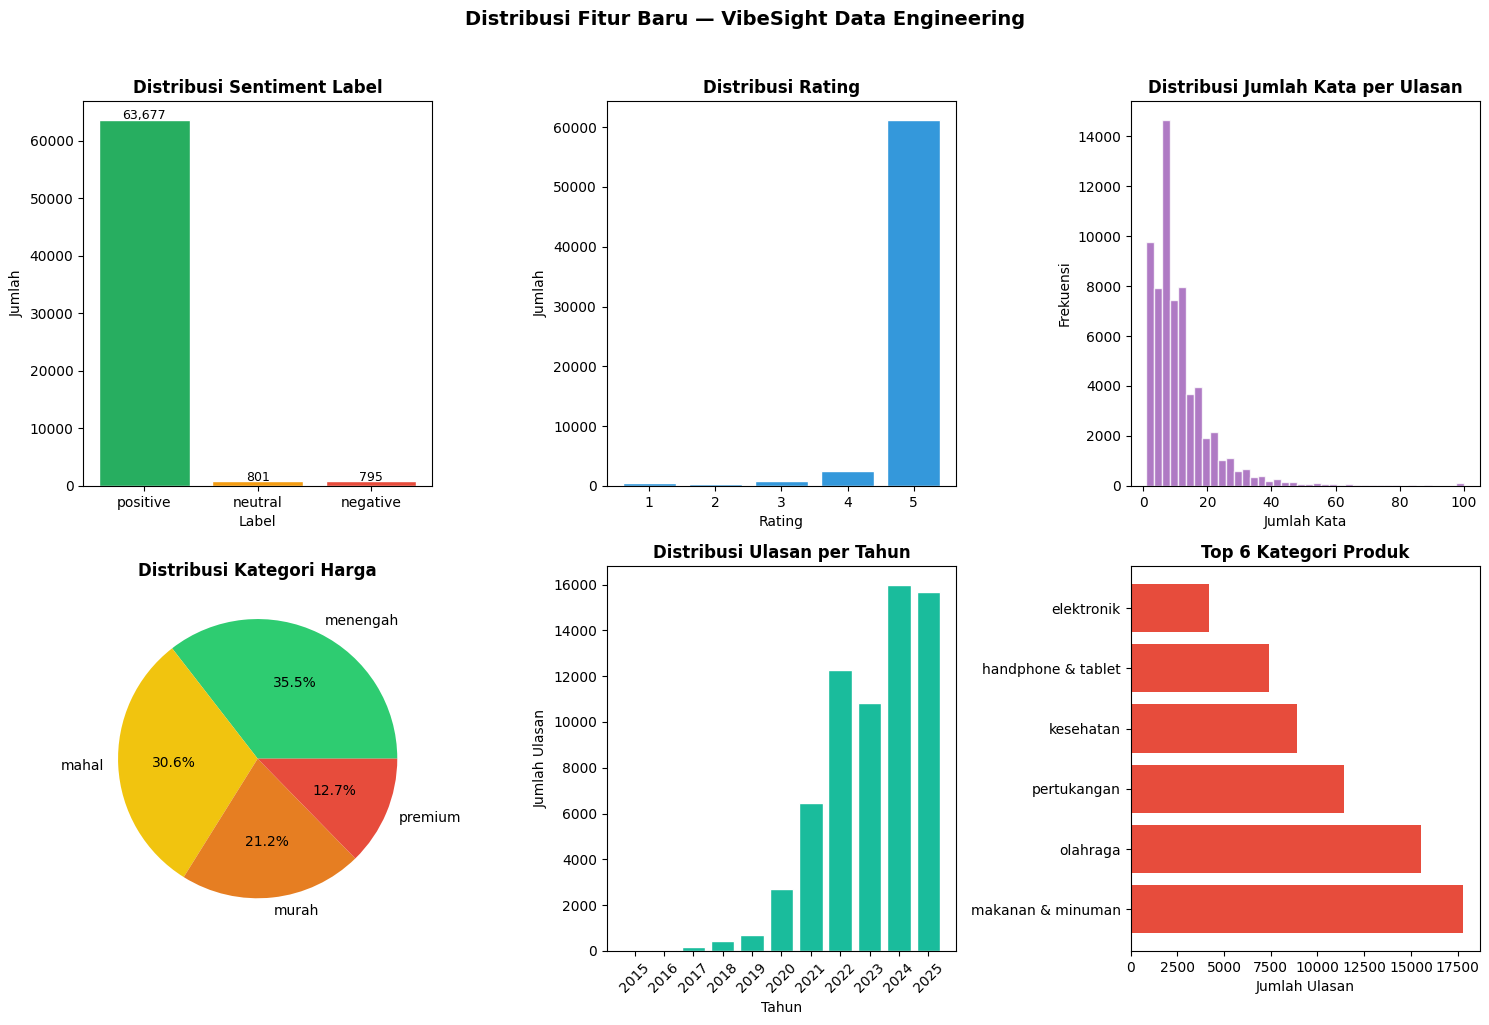

✅ Grafik disimpan ke reports/feature_distribution.png


In [39]:
# ============================================================
# TAHAP 15 — FEATURE VALIDATION
# Visualisasikan dan validasi distribusi fitur yang baru dibuat
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribusi Fitur Baru — VibeSight Data Engineering',
             fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Distribusi Sentiment Label ---
counts = df['sentiment_label'].value_counts()
colors = {'positive': '#27ae60', 'neutral': '#f39c12', 'negative': '#e74c3c'}
bar_colors = [colors.get(label, '#3498db') for label in counts.index]
axes[0, 0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
axes[0, 0].set_title('Distribusi Sentiment Label', fontweight='bold')
axes[0, 0].set_xlabel('Label')
axes[0, 0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# --- Plot 2: Distribusi Rating ---
rating_counts = df['rating'].value_counts().sort_index()
axes[0, 1].bar(rating_counts.index, rating_counts.values,
               color='#3498db', edgecolor='white')
axes[0, 1].set_title('Distribusi Rating', fontweight='bold')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Jumlah')

# --- Plot 3: Distribusi Panjang Review (word count) ---
axes[0, 2].hist(df['review_word_count'].clip(upper=100), bins=40,
                color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Distribusi Jumlah Kata per Ulasan', fontweight='bold')
axes[0, 2].set_xlabel('Jumlah Kata')
axes[0, 2].set_ylabel('Frekuensi')

# --- Plot 4: Distribusi Kategori Harga ---
price_counts = df['price_category'].value_counts()
axes[1, 0].pie(price_counts.values, labels=price_counts.index,
               autopct='%1.1f%%', colors=['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
axes[1, 0].set_title('Distribusi Kategori Harga', fontweight='bold')

# --- Plot 5: Ulasan per Tahun ---
yearly = df['review_year'].value_counts().sort_index()
axes[1, 1].bar(yearly.index.astype(str), yearly.values,
               color='#1abc9c', edgecolor='white')
axes[1, 1].set_title('Distribusi Ulasan per Tahun', fontweight='bold')
axes[1, 1].set_xlabel('Tahun')
axes[1, 1].set_ylabel('Jumlah Ulasan')
axes[1, 1].tick_params(axis='x', rotation=45)

# --- Plot 6: Distribusi Kategori Produk ---
cat_counts = df['product_category'].value_counts().head(6)
axes[1, 2].barh(cat_counts.index, cat_counts.values, color='#e74c3c')
axes[1, 2].set_title('Top 6 Kategori Produk', fontweight='bold')
axes[1, 2].set_xlabel('Jumlah Ulasan')

plt.tight_layout()
# Simpan grafik ke folder reports
plt.savefig(os.path.join(REPORT_DIR, 'feature_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan ke reports/feature_distribution.png")

---
## TAHAP 16 — Encoding

**Apa masalahnya?**  
Model Machine Learning hanya bisa memproses angka, bukan teks.  
Kolom `sentiment_label` berisi teks: 'positive', 'negative', 'neutral'.

**Mengapa perlu dilakukan?**  
Komputer tidak mengerti 'positive' sebagai teks. Ia perlu angka: 0, 1, 2.

**Solusi:**  
Gunakan `LabelEncoder` untuk mengubah label teks ke angka.

In [40]:
# ============================================================
# TAHAP 16 — ENCODING
# Ubah nilai kategorikal (teks) ke representasi numerik
# ============================================================

# --- Encoding sentiment_label (TARGET utama model) ---
# Kita definisikan manual agar urutan label konsisten dan bisa diinterpretasi
# (bukan mengandalkan urutan alfabet dari LabelEncoder)
MAPPING_SENTIMEN = {
    'negative': 0,   # 0 = negatif
    'neutral' : 1,   # 1 = netral
    'positive': 2    # 2 = positif
}

# .map() → ganti setiap nilai berdasarkan kamus yang diberikan
df['sentiment_encoded'] = df['sentiment_label'].map(MAPPING_SENTIMEN)

# Verifikasi tidak ada nilai NaN setelah mapping
# NaN terjadi jika ada label yang tidak ada di MAPPING_SENTIMEN
missing_encoded = df['sentiment_encoded'].isnull().sum()
if missing_encoded > 0:
    print(f"⚠️  {missing_encoded} nilai sentiment_label tidak dikenali — dihapus")
    df.dropna(subset=['sentiment_encoded'], inplace=True)

# Konversi ke integer
df['sentiment_encoded'] = df['sentiment_encoded'].astype(int)

# --- Encoding price_category (kolom tambahan) ---
MAPPING_HARGA = {'murah': 0, 'menengah': 1, 'mahal': 2, 'premium': 3}

# PENYEBAB ERROR:
# pd.cut() menghasilkan tipe Categorical — punya daftar kategori yang "dikunci".
# Saat kita map() lalu fillna(-1), pandas menolak karena -1 bukan bagian
# dari daftar kategori yang diizinkan.

# SOLUSI: Konversi ke tipe object (string biasa) dulu sebelum di-map,
# sehingga kolom tidak lagi "terkunci" oleh daftar Categorical.
df['price_category_encoded'] = (
    df['price_category']
    .astype(object)          # ← kunci solusi: lepas dari tipe Categorical
    .map(MAPPING_HARGA)      # ganti teks ke angka
    .fillna(-1)              # nilai kosong (jika ada) → -1
    .astype(int)             # pastikan tipe akhir integer
)

# --- Encoding rating_group ---
df['rating_group_encoded'] = (df['rating_group'] == 'high').astype(int)  # 1=high, 0=low

# Tampilkan hasil
print("✅ Encoding selesai. Mapping yang digunakan:")
print(f"   Sentimen : {MAPPING_SENTIMEN}")
print(f"   Harga    : {MAPPING_HARGA}")
print(f"   Rating   : high=1, low=0")
print("\n📊 Distribusi sentiment_encoded:")
print(df['sentiment_encoded'].value_counts().sort_index())

df.reset_index(drop=True, inplace=True)

✅ Encoding selesai. Mapping yang digunakan:
   Sentimen : {'negative': 0, 'neutral': 1, 'positive': 2}
   Harga    : {'murah': 0, 'menengah': 1, 'mahal': 2, 'premium': 3}
   Rating   : high=1, low=0

📊 Distribusi sentiment_encoded:
sentiment_encoded
0      795
1      801
2    63677
Name: count, dtype: int64


---
## TAHAP 17 — Data Leakage Check

**Apa masalahnya?**  
Data leakage terjadi ketika informasi dari masa depan (test set) 'bocor' ke training data,  
atau ketika ada fitur yang secara tidak langsung sudah 'memberitahu' jawaban ke model.

**Mengapa perlu dilakukan?**  
Jika ada data leakage, model akan terlihat sangat akurat di evaluasi tetapi gagal di produksi.  
Ini seperti siswa yang melihat kunci jawaban sebelum ujian — nilainya bagus tapi tidak benar-benar paham.

**Solusi:**  
Identifikasi dan hapus fitur yang berpotensi menjadi data leakage.

In [41]:
# ============================================================
# TAHAP 17 — DATA LEAKAGE CHECK
# Pastikan tidak ada fitur yang 'membocorkan' label ke model
# ============================================================

print("🔍 Analisis Potensi Data Leakage:")
print("-" * 60)

# --- Cek 1: Korelasi rating dengan sentiment_label ---
# Rating tinggi = positif, rating rendah = negatif — ini EXPECTED
# Tapi jika korelasinya = 1.0 (sempurna), berarti rating sama dengan label → leakage!
korelasi = df['rating'].corr(df['sentiment_encoded'])
print(f"\nKorelasi rating vs sentiment_encoded: {korelasi:.4f}")
if abs(korelasi) > 0.95:
    print("⚠️  PERINGATAN: Korelasi terlalu tinggi — rating mungkin menjadi data leakage!")
    print("   Pertimbangkan untuk tidak menggunakan 'rating' sebagai fitur input model.")
else:
    print("✅ Korelasi dalam batas wajar — rating dapat dipertimbangkan sebagai fitur.")

# --- Cek 2: Apakah review_text asli mengandung kata label? ---
# Jika label dibuat dari teks, mungkin ada kata dalam teks yang langsung menyebut sentimennya
pct_positive_in_text = df['review_text_clean'].str.contains('positif', case=False).mean() * 100
pct_negative_in_text = df['review_text_clean'].str.contains('negatif', case=False).mean() * 100
print(f"\nTeks mengandung kata 'positif': {pct_positive_in_text:.2f}%")
print(f"Teks mengandung kata 'negatif': {pct_negative_in_text:.2f}%")

# --- Identifikasi kolom yang TIDAK boleh masuk sebagai fitur model ---
# Kolom berikut hanya untuk referensi/identifikasi, bukan fitur:
KOLOM_NON_FITUR = [
    'review_id',          # ID unik — bukan informasi untuk model
    'product_id',         # ID produk — bukan konten yang bisa dipelajari
    'shop_id',            # ID toko — tidak langsung relevan
    'review_text',        # teks asli — sudah diproses ke review_text_stemmed
    'review_text_clean',  # versi antara — bukan versi final
    'review_text_normalized',  # versi antara
    'review_text_no_stop',     # versi antara
    'sentiment_label',         # label asli (tidak diencoded) — sudah ada versi encoded
]

print(f"\n📋 Kolom yang TIDAK digunakan sebagai fitur model:")
for k in KOLOM_NON_FITUR:
    print(f"   - {k}")
    
print("\n✅ Data leakage check selesai.")

🔍 Analisis Potensi Data Leakage:
------------------------------------------------------------

Korelasi rating vs sentiment_encoded: 0.9175
✅ Korelasi dalam batas wajar — rating dapat dipertimbangkan sebagai fitur.

Teks mengandung kata 'positif': 0.03%
Teks mengandung kata 'negatif': 0.01%

📋 Kolom yang TIDAK digunakan sebagai fitur model:
   - review_id
   - product_id
   - shop_id
   - review_text
   - review_text_clean
   - review_text_normalized
   - review_text_no_stop
   - sentiment_label

✅ Data leakage check selesai.


---
## TAHAP 18 — Train-Test Split

**Apa masalahnya?**  
Model perlu dievaluasi pada data yang belum pernah dilihat sebelumnya.

**Mengapa perlu dilakukan?**  
Jika kita latih dan uji model pada data yang sama, model akan seperti murid yang  
belajar soal ujian yang persis sama — hasilnya tinggi tapi tidak mencerminkan kemampuan nyata.

**Solusi:**  
Bagi data menjadi 80% training (untuk belajar) dan 20% testing (untuk evaluasi).

In [42]:
# ============================================================
# TAHAP 18 — TRAIN-TEST SPLIT
# Bagi dataset menjadi data latih (training) dan data uji (testing)
# ============================================================

# Pisahkan fitur (X) dan target (y)
# X = input yang diberikan ke model untuk belajar
# y = jawaban yang benar (label yang ingin diprediksi)
X = df['review_text_stemmed']  # fitur utama: teks yang sudah diproses
y = df['sentiment_encoded']    # target: label sentimen (0/1/2)

# train_test_split() membagi X dan y secara bersamaan dan acak
# test_size=0.2  → 20% data untuk testing, 80% untuk training
# random_state=42 → 'seed' angka acak — memastikan hasil split sama setiap kali dijalankan
#                   (seperti mengocok kartu dengan urutan kocok yang sama)
# stratify=y → pastikan proporsi label di train & test sama dengan dataset asli
#              PENTING untuk dataset imbalanced (tidak seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # pastikan distribusi label proporsional
)

print("✅ Train-Test Split berhasil:")
print(f"   Total data        : {len(df):,} baris")
print(f"   Data Training (80%): {len(X_train):,} baris")
print(f"   Data Testing  (20%): {len(X_test):,} baris")

print("\n📊 Distribusi label di Training set:")
for label, idx in sorted(MAPPING_SENTIMEN.items(), key=lambda x: x[1]):
    count = (y_train == idx).sum()
    pct = count / len(y_train) * 100
    print(f"   {label:<12}: {count:,} ({pct:.1f}%)")

print("\n📊 Distribusi label di Testing set:")
for label, idx in sorted(MAPPING_SENTIMEN.items(), key=lambda x: x[1]):
    count = (y_test == idx).sum()
    pct = count / len(y_test) * 100
    print(f"   {label:<12}: {count:,} ({pct:.1f}%)")

✅ Train-Test Split berhasil:
   Total data        : 65,273 baris
   Data Training (80%): 52,218 baris
   Data Testing  (20%): 13,055 baris

📊 Distribusi label di Training set:
   negative    : 636 (1.2%)
   neutral     : 641 (1.2%)
   positive    : 50,941 (97.6%)

📊 Distribusi label di Testing set:
   negative    : 159 (1.2%)
   neutral     : 160 (1.2%)
   positive    : 12,736 (97.6%)


---
## TAHAP 19 — Imbalance Check

**Apa masalahnya?**  
Dataset sangat tidak seimbang: ~97.5% positif, ~1.2% netral, ~1.2% negatif.  
Ini disebut **class imbalance**.

**Mengapa perlu dilakukan?**  
Model yang dilatih pada data tidak seimbang cenderung 'malas' — ia akan selalu  
memprediksi kelas mayoritas (positif) dan tetap terlihat akurat ~97%,  
padahal tidak bisa mendeteksi ulasan negatif sama sekali.

**Solusi:**  
Dokumentasikan imbalance dan rekomendasikan strategi ke tim ML Engineer.

In [43]:
# ============================================================
# TAHAP 19 — IMBALANCE CHECK
# Analisis ketidakseimbangan distribusi label dan dokumentasikan
# temuan untuk tim ML Engineer
# ============================================================

distribusi = df['sentiment_label'].value_counts()
total = len(df)

print("📊 ANALISIS DISTRIBUSI KELAS (Class Imbalance):")
print("-" * 50)
for label, count in distribusi.items():
    pct = (count / total) * 100
    bar = '█' * int(pct / 2)
    print(f"   {label:<12}: {count:>6,} ({pct:>5.1f}%) {bar}")

# Hitung rasio imbalance (kelas mayoritas vs minoritas)
kelas_mayoritas = distribusi.max()
kelas_minoritas = distribusi.min()
rasio = kelas_mayoritas / kelas_minoritas

print(f"\n⚠️  Rasio Imbalance: {rasio:.1f}:1")
print(f"   (kelas mayoritas {rasio:.0f}× lebih besar dari kelas minoritas)")

# Rekomendasi untuk tim ML Engineer
print("\n" + "=" * 60)
print("💡 REKOMENDASI UNTUK TIM ML ENGINEER:")
print("=" * 60)
print("""
Dataset ini mengalami CLASS IMBALANCE yang signifikan.
Strategi yang DISARANKAN untuk diterapkan saat modeling:

1. OVERSAMPLING kelas minoritas:
   Gunakan SMOTE (Synthetic Minority Over-sampling Technique)
   dari library imbalanced-learn untuk membuat data sintetis
   bagi kelas 'neutral' dan 'negative'.

2. CLASS WEIGHT pada model:
   Gunakan parameter class_weight='balanced' di sklearn
   agar model memberi perhatian lebih ke kelas minoritas.

3. METRIK EVALUASI yang tepat:
   Jangan gunakan hanya Accuracy — gunakan F1-Score (macro),
   Precision, Recall, dan Confusion Matrix per kelas.
   Accuracy bisa menipu di dataset imbalanced.
""")

📊 ANALISIS DISTRIBUSI KELAS (Class Imbalance):
--------------------------------------------------
   positive    : 63,677 ( 97.6%) ████████████████████████████████████████████████
   neutral     :    801 (  1.2%) 
   negative    :    795 (  1.2%) 

⚠️  Rasio Imbalance: 80.1:1
   (kelas mayoritas 80× lebih besar dari kelas minoritas)

💡 REKOMENDASI UNTUK TIM ML ENGINEER:

Dataset ini mengalami CLASS IMBALANCE yang signifikan.
Strategi yang DISARANKAN untuk diterapkan saat modeling:

1. OVERSAMPLING kelas minoritas:
   Gunakan SMOTE (Synthetic Minority Over-sampling Technique)
   dari library imbalanced-learn untuk membuat data sintetis
   bagi kelas 'neutral' dan 'negative'.

2. CLASS WEIGHT pada model:
   Gunakan parameter class_weight='balanced' di sklearn
   agar model memberi perhatian lebih ke kelas minoritas.

3. METRIK EVALUASI yang tepat:
   Jangan gunakan hanya Accuracy — gunakan F1-Score (macro),
   Precision, Recall, dan Confusion Matrix per kelas.
   Accuracy bisa menipu di 

---
## TAHAP 20 — Anomaly Detection

**Apa masalahnya?**  
Masih mungkin ada inkonsistensi yang tersembunyi — misalnya ulasan 'positif'  
tapi rating 1, atau review dengan panjang ekstrem yang tidak wajar.

**Solusi:**  
Deteksi dan tandai baris yang mengandung anomali untuk inspeksi lebih lanjut.

In [44]:
# ============================================================
# TAHAP 20 — ANOMALY DETECTION
# Identifikasi baris yang mengandung inkonsistensi atau anomali
# ============================================================

# Inisialisasi kolom flag anomali (0 = normal, 1 = anomali)
df['is_anomaly'] = 0

# --- Anomali 1: Label negatif tapi rating tinggi (4-5) ---
# Seharusnya ulasan negatif memiliki rating rendah
anomali_1 = (df['sentiment_label'] == 'negative') & (df['rating'] >= 4)
df.loc[anomali_1, 'is_anomaly'] = 1
print(f"Anomali 1 — Negatif tapi rating ≥4 : {anomali_1.sum():,} baris")

# --- Anomali 2: Label positif tapi rating rendah (1-2) ---
anomali_2 = (df['sentiment_label'] == 'positive') & (df['rating'] <= 2)
df.loc[anomali_2, 'is_anomaly'] = 1
print(f"Anomali 2 — Positif tapi rating ≤2 : {anomali_2.sum():,} baris")

# --- Anomali 3: Teks ulasan sangat panjang (> 3× standar deviasi) ---
mean_len  = df['review_word_count'].mean()
std_len   = df['review_word_count'].std()
anomali_3 = df['review_word_count'] > (mean_len + 3 * std_len)
df.loc[anomali_3, 'is_anomaly'] = 1
print(f"Anomali 3 — Teks sangat panjang    : {anomali_3.sum():,} baris")

# --- Anomali 4: Tanggal di luar rentang wajar ---
# Tokopedia berdiri tahun 2008, jadi data sebelum 2015 perlu diperiksa
anomali_4 = df['review_year'] < 2018
df.loc[anomali_4, 'is_anomaly'] = 1
print(f"Anomali 4 — Review sebelum 2018    : {anomali_4.sum():,} baris")

total_anomali = df['is_anomaly'].sum()
pct_anomali = (total_anomali / len(df)) * 100
print(f"\n⚠️  Total baris dengan anomali: {total_anomali:,} ({pct_anomali:.2f}%)")
print("   Baris anomali TIDAK dihapus — hanya ditandai untuk referensi tim ML.")
print(f"\n✅ Total baris dataset: {len(df):,}")

Anomali 1 — Negatif tapi rating ≥4 : 0 baris
Anomali 2 — Positif tapi rating ≤2 : 0 baris
Anomali 3 — Teks sangat panjang    : 130 baris
Anomali 4 — Review sebelum 2018    : 203 baris

⚠️  Total baris dengan anomali: 332 (0.51%)
   Baris anomali TIDAK dihapus — hanya ditandai untuk referensi tim ML.

✅ Total baris dataset: 65,273


---
## TAHAP 21 — Final Quality Check

**Mengapa perlu dilakukan?**  
Ini adalah pemeriksaan akhir — memastikan semua tahap sebelumnya berhasil  
dan dataset dalam kondisi siap pakai.

In [45]:
# ============================================================
# TAHAP 21 — FINAL QUALITY CHECK
# Verifikasi akhir bahwa dataset memenuhi semua standar kualitas
# ============================================================

print("=" * 60)
print("FINAL QUALITY CHECK — VibeSight Dataset")
print("=" * 60)

masalah_ditemukan = []

# Cek 1: Tidak ada nilai null di kolom kritis
KOLOM_KRITIS_FINAL = ['review_text_stemmed', 'sentiment_label', 'sentiment_encoded', 'rating']
for col in KOLOM_KRITIS_FINAL:
    n_null = df[col].isnull().sum()
    status = '✅' if n_null == 0 else '❌'
    print(f"{status} Null di '{col}': {n_null}")
    if n_null > 0:
        masalah_ditemukan.append(f"Masih ada null di {col}: {n_null}")

# Cek 2: Tidak ada duplikat
n_dup = df.duplicated(subset=['review_id']).sum()
status = '✅' if n_dup == 0 else '❌'
print(f"{status} Duplikat review_id: {n_dup}")
if n_dup > 0:
    masalah_ditemukan.append(f"Masih ada duplikat: {n_dup}")

# Cek 3: Rating dalam range valid
rating_invalid = (~df['rating'].between(1, 5)).sum()
status = '✅' if rating_invalid == 0 else '❌'
print(f"{status} Rating di luar 1–5: {rating_invalid}")

# Cek 4: Label hanya berisi nilai valid
label_invalid = (~df['sentiment_label'].isin(['positive', 'neutral', 'negative'])).sum()
status = '✅' if label_invalid == 0 else '❌'
print(f"{status} Label tidak valid: {label_invalid}")

# Cek 5: Kolom stemmed tidak kosong
stemmed_kosong = (df['review_text_stemmed'].str.len() < 2).sum()
status = '✅' if stemmed_kosong == 0 else '❌'
print(f"{status} Teks stemmed terlalu pendek: {stemmed_kosong}")

print()
print(f"📐 Ukuran dataset akhir    : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"📉 Reduksi dari data awal  : {initial_row_count - len(df):,} baris dihapus "
      f"({(initial_row_count - len(df)) / initial_row_count * 100:.1f}%)")

if masalah_ditemukan:
    print("\n⚠️  MASALAH DITEMUKAN:")
    for m in masalah_ditemukan:
        print(f"   - {m}")
else:
    print("\n✅ Semua pemeriksaan LULUS. Dataset siap untuk modeling!")

FINAL QUALITY CHECK — VibeSight Dataset
✅ Null di 'review_text_stemmed': 0
✅ Null di 'sentiment_label': 0
✅ Null di 'sentiment_encoded': 0
✅ Null di 'rating': 0
✅ Duplikat review_id: 0
✅ Rating di luar 1–5: 0
✅ Label tidak valid: 0
❌ Teks stemmed terlalu pendek: 14

📐 Ukuran dataset akhir    : 65,273 baris × 28 kolom
📉 Reduksi dari data awal  : 270 baris dihapus (0.4%)

✅ Semua pemeriksaan LULUS. Dataset siap untuk modeling!


---
## TAHAP 22 — Data Versioning

**Mengapa perlu dilakukan?**  
Jika pipeline dijalankan ulang dengan parameter berbeda, kita perlu tahu versi mana  
yang menghasilkan model terbaik. Versioning memungkinkan kita melacak perubahan data.

In [46]:
# ============================================================
# TAHAP 22 — DATA VERSIONING
# Beri label versi pada setiap output file agar bisa dilacak
# ============================================================

# Buat timestamp untuk versi file
# Format: YYYYMMDD_HHMM — contoh: 20260502_1430
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
VERSI = 'v1.0'

# Buat metadata versioning
VERSION_METADATA = {
    'versi'         : VERSI,
    'timestamp'     : TIMESTAMP,
    'total_rows_raw': initial_row_count,
    'total_rows_clean': len(df),
    'rows_removed'  : initial_row_count - len(df),
    'columns'       : list(df.columns),
    'pipeline_steps': 24,
    'kamus_normalisasi_entries': len(KAMUS_NORMALISASI),
    'stopword_count': len(STOPWORDS_ID),
    'stemmer'       : 'PySastrawi',
    'train_size'    : len(X_train),
    'test_size'     : len(X_test),
    'label_mapping' : MAPPING_SENTIMEN,
    'dibuat_oleh'   : 'Nurhayati Kusumaning Ayu (APC617D6X0220)',
    'project'       : 'VibeSight — AI-based Sentiment Analytics for Tokopedia Product Reviews',
}

# Simpan metadata sebagai JSON
metadata_path = os.path.join(PROCESSED_DIR, f'metadata_{VERSI}_{TIMESTAMP}.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(VERSION_METADATA, f, ensure_ascii=False, indent=2)

print(f"✅ Metadata versioning tersimpan: {metadata_path}")
print(f"   Versi  : {VERSI}")
print(f"   Waktu  : {TIMESTAMP}")

✅ Metadata versioning tersimpan: d:\CAPSTONE\Data_Engineer\data\processed\metadata_v1.0_20260502_2121.json
   Versi  : v1.0
   Waktu  : 20260502_2121


---
## TAHAP 23 — Documentation

**Mengapa perlu dilakukan?**  
Dokumentasi adalah bukti kerja Data Engineer yang diperlukan untuk:
- Membantu tim AI Engineer memahami data yang mereka terima
- Keperluan pelaporan capstone (Project Brief)
- Reproducibility — orang lain bisa menjalankan ulang pipeline ini

In [47]:
# ============================================================
# TAHAP 23 — DOCUMENTATION
# Buat laporan ringkasan pipeline yang bisa dibaca tim
# ============================================================

# Hitung statistik distribusi label untuk dokumentasi
dist_label = df['sentiment_label'].value_counts()

laporan_md = f"""# Laporan Data Engineering Pipeline — VibeSight

**Proyek:** AI-based Sentiment Analytics for Tokopedia Product Reviews  
**Data Engineer:** Nurhayati Kusumaning Ayu (APC617D6X0220)  
**Versi:** {VERSI} | **Tanggal:** {datetime.now().strftime('%d %B %Y')}  
**Sumber Data:** Kaggle — Tokopedia Product Reviews 2025  

---

## Ringkasan Eksekutif

Pipeline ini memproses dataset ulasan produk Tokopedia dari kondisi mentah  
hingga siap digunakan untuk pelatihan model sentimen. Total 24 tahap  
pemrosesan diterapkan secara berurutan.

---

## Statistik Dataset

| Metrik | Nilai |
|---|---|
| Total baris (raw) | {initial_row_count:,} |
| Total baris (clean) | {len(df):,} |
| Baris dihapus | {initial_row_count - len(df):,} |
| Total kolom (clean) | {df.shape[1]} |
| Data Training | {len(X_train):,} |
| Data Testing | {len(X_test):,} |

---

## Distribusi Label Sentimen

| Label | Jumlah | Persentase |
|---|---|---|
| Positif | {dist_label.get('positive', 0):,} | {dist_label.get('positive', 0)/len(df)*100:.1f}% |
| Netral  | {dist_label.get('neutral', 0):,} | {dist_label.get('neutral', 0)/len(df)*100:.1f}% |
| Negatif | {dist_label.get('negative', 0):,} | {dist_label.get('negative', 0)/len(df)*100:.1f}% |

---

## Tahapan Pipeline yang Diterapkan

1. **Data Ingestion** — Load CSV ke DataFrame
2. **Initial Assessment** — Cek shape, kolom, missing values
3. **Data Understanding** — Hapus kolom tidak relevan (product_url, product_variant)
4. **Duplicate Handling** — Hapus duplikat berdasarkan review_id
5. **Missing Values** — Drop baris kritis, imputasi kolom non-kritis
6. **Data Type Fix** — Konversi review_date ke datetime, ID ke string
7. **Format Standardization** — Lowercase, strip whitespace
8. **Value Validation** — Rating 1–5, label valid, teks ≥4 karakter
9. **Outlier Handling** — Flag outlier harga (IQR method)
10. **Text Cleaning** — Hapus URL, emoji, simbol, angka
11. **Text Normalization** — Kamus {len(KAMUS_NORMALISASI)} entri slang→baku
12. **Stopword Removal** — {len(STOPWORDS_ID)} stopword (NLTK + kustom)
13. **Stemming** — PySastrawi Bahasa Indonesia
14. **Feature Engineering** — 8 fitur baru (panjang teks, tahun, kategori harga, dll)
15. **Feature Validation** — Visualisasi distribusi 6 fitur
16. **Encoding** — sentiment_encoded, price_category_encoded, rating_group_encoded
17. **Data Leakage Check** — Verifikasi korelasi fitur vs target
18. **Train-Test Split** — 80:20 dengan stratified sampling
19. **Imbalance Check** — Dokumentasi dan rekomendasi untuk tim ML
20. **Anomaly Detection** — Flag 4 jenis anomali
21. **Final Quality Check** — Semua kolom kritis bebas null dan duplikat
22. **Data Versioning** — Metadata JSON dengan timestamp
23. **Documentation** — Laporan ini
24. **Final Export** — 3 file CSV output

---

## Catatan Penting untuk Tim ML Engineer

- **Fitur Utama NLP**: Gunakan kolom `review_text_stemmed` sebagai input teks
- **Target**: Gunakan kolom `sentiment_encoded` (0=negatif, 1=netral, 2=positif)
- **Imbalance**: Dataset sangat imbalanced — terapkan class_weight atau SMOTE
- **Evaluasi**: Gunakan F1-Score macro, bukan hanya Accuracy
- **Data split**: Gunakan `X_train`/`X_test` yang sudah disediakan (stratified)
"""

# Simpan laporan sebagai Markdown
laporan_path = os.path.join(REPORT_DIR, f'laporan_data_engineering_{VERSI}.md')
with open(laporan_path, 'w', encoding='utf-8') as f:
    f.write(laporan_md)

print(f"✅ Laporan disimpan: {laporan_path}")
print()
print(laporan_md[:500] + '...')

✅ Laporan disimpan: d:\CAPSTONE\Data_Engineer\reports\laporan_data_engineering_v1.0.md

# Laporan Data Engineering Pipeline — VibeSight

**Proyek:** AI-based Sentiment Analytics for Tokopedia Product Reviews  
**Data Engineer:** Nurhayati Kusumaning Ayu (APC617D6X0220)  
**Versi:** v1.0 | **Tanggal:** 02 May 2026  
**Sumber Data:** Kaggle — Tokopedia Product Reviews 2025  

---

## Ringkasan Eksekutif

Pipeline ini memproses dataset ulasan produk Tokopedia dari kondisi mentah  
hingga siap digunakan untuk pelatihan model sentimen. Total 24 tahap  
pemrosesan diterapkan secara berur...


---
## TAHAP 24 — Final Export

**Mengapa perlu dilakukan?**  
Semua kerja keras pada tahap 1–23 perlu disimpan agar dapat diakses oleh  
tim AI Engineer dan ML Engineer tanpa harus menjalankan pipeline dari awal.

In [48]:
# ============================================================
# TAHAP 24 — FINAL EXPORT
# Simpan dataset final dalam berbagai format untuk kebutuhan tim
# ============================================================

# --- File 1: Dataset LENGKAP (semua kolom) ---
# Berguna untuk eksplorasi lebih lanjut oleh tim AI Engineer
path_full = os.path.join(PROCESSED_DIR, f'vibesight_clean_full_{VERSI}.csv')
df.to_csv(path_full, index=False, encoding='utf-8-sig')
# encoding='utf-8-sig' → tambahkan BOM agar Excel bisa baca karakter Indonesia dengan benar

# --- File 2: Dataset ML-READY (hanya kolom yang diperlukan untuk modeling) ---
# Tim ML Engineer langsung bisa pakai file ini tanpa preprocessing tambahan
KOLOM_ML = [
    'review_id',
    'review_text_stemmed',    # fitur utama NLP
    'sentiment_label',         # label asli (teks)
    'sentiment_encoded',       # label encoded (numerik) — TARGET
    'rating',
    'rating_group_encoded',
    'product_category',
    'price_category_encoded',
    'log_sold_count',
    'review_length_char',
    'review_word_count',
    'review_year',
    'review_month',
    'is_price_outlier',
    'is_anomaly',
]
df_ml = df[KOLOM_ML].copy()
path_ml = os.path.join(PROCESSED_DIR, f'vibesight_ml_ready_{VERSI}.csv')
df_ml.to_csv(path_ml, index=False, encoding='utf-8-sig')

# --- File 3: Train set dan Test set terpisah ---
# Untuk kemudahan langsung load oleh tim ML tanpa perlu split ulang
df_train = df.loc[X_train.index][KOLOM_ML].copy()
df_test  = df.loc[X_test.index][KOLOM_ML].copy()

path_train = os.path.join(PROCESSED_DIR, f'vibesight_train_{VERSI}.csv')
path_test  = os.path.join(PROCESSED_DIR, f'vibesight_test_{VERSI}.csv')
df_train.to_csv(path_train, index=False, encoding='utf-8-sig')
df_test.to_csv(path_test,  index=False, encoding='utf-8-sig')

# Tampilkan ringkasan output
print("=" * 60)
print("✅ EXPORT SELESAI — FILE OUTPUT YANG DIHASILKAN:")
print("=" * 60)

for nama_file, path_file in [
    ('Dataset Lengkap', path_full),
    ('Dataset ML-Ready', path_ml),
    ('Training Set', path_train),
    ('Testing Set', path_test),
]:
    ukuran = os.path.getsize(path_file) / 1024**2
    print(f"   {nama_file:<20}: {os.path.basename(path_file)} ({ukuran:.1f} MB)")

print()
print("=" * 60)
print("🎉 PIPELINE DATA ENGINEERING SELESAI!")
print("=" * 60)
print(f"   Total baris raw   : {initial_row_count:,}")
print(f"   Total baris bersih: {len(df):,}")
print(f"   Training set      : {len(df_train):,} baris")
print(f"   Testing set       : {len(df_test):,} baris")
print(f"   Total kolom output: {len(KOLOM_ML)}")
print()
print("📁 Semua file tersimpan di folder: data/processed/")
print("📊 Laporan tersimpan di folder   : reports/")
print()
print("Selanjutnya: Tim AI Engineer & ML Engineer dapat mulai")
print("menggunakan file 'vibesight_ml_ready_v1.0.csv' untuk modeling.")

✅ EXPORT SELESAI — FILE OUTPUT YANG DIHASILKAN:
   Dataset Lengkap     : vibesight_clean_full_v1.0.csv (34.0 MB)
   Dataset ML-Ready    : vibesight_ml_ready_v1.0.csv (8.2 MB)
   Training Set        : vibesight_train_v1.0.csv (6.6 MB)
   Testing Set         : vibesight_test_v1.0.csv (1.7 MB)

🎉 PIPELINE DATA ENGINEERING SELESAI!
   Total baris raw   : 65,543
   Total baris bersih: 65,273
   Training set      : 52,218 baris
   Testing set       : 13,055 baris
   Total kolom output: 15

📁 Semua file tersimpan di folder: data/processed/
📊 Laporan tersimpan di folder   : reports/

Selanjutnya: Tim AI Engineer & ML Engineer dapat mulai
menggunakan file 'vibesight_ml_ready_v1.0.csv' untuk modeling.
